In [1]:
import numpy as np
import pandas as pd
import scipy
import matplotlib.pyplot as plt
# import sys
# import os
from scr.fluid import Fluid
from scr.reservoir import Reservoir, ResProps
from scr.well import Well
from scr.pipe import Pipe
from scr.state import NodeState
from scr.compressor import DCS
# from scr.simulator import Simulator # ошибка, необходим импорт модуля pd

In [2]:
with open('interp_data.csv', 'r', encoding='utf-8') as file:
    file_PVT = pd.DataFrame(pd.read_csv(file, sep=';'))

In [3]:
# Инициализация классов для расчёта

# Свойства флюида
rho_c = 0.6799  # значение плотности
xa = 0.4319     # мольная доля азота
xy = 0.2912     # мольная доля CO₂
M = 16.36       # молярная масса

# Свойства плата
pres = 100 # атм
temp = 310 # К
vol = np.pi*500**2*25 # м3

# Свойства скважины (забой)
k = 50 # мД
h = 25 # м
rw = 0.1 # м
re = 500 # 

# Свойства скважины (ствол)
D_nkt = 0.062 # м
D = 0.1 # м
L = 2000 # м, длина по стволу
roughness = 0.000046 # м
vertical_depth = 2000 # м


fluid = Fluid(M=M, rho_c=rho_c, xa=xa, xy=xy, T=300, file_PVT=file_PVT)
resprops = ResProps(pres, vol, temp)
reservoir = Reservoir(resprops, fluid)
wellbore = Pipe(L,D,roughness,fluid,vertical_depth)
line_pipe = Pipe(L,D,roughness,fluid,0)
well = Well(fluid,k,h,re,rw,wellbore)

In [4]:
well_name = 'Well_1'
well_state = NodeState(well_name, 100, 50, 50, 300, None, None, None)

In [5]:
well_state.get_state()

{'name': 'Well_1',
 'P_in': 100,
 'P_out': 50,
 'dP': 50,
 'q_std': 300,
 'q_res': None,
 'v': None,
 'rho': None}

In [7]:
compressor = DCS(CR=1.5, P_line=80, q_ext=0)

In [9]:
well_state = NodeState(well_name, [], [], [], [], None, None, None)

for i in range(1, 5):
    BHP = i*10
    q = well.q(resprops.P, BHP)
    BHP_i = well.bhp(float(BHP), q)
    q = well.q(resprops.P, BHP_i)

    well_state.q_std.append(q)
    well_state.P_in.append(BHP_i)
    well_state.P_out.append(BHP)
    


TypeError: only 0-dimensional arrays can be converted to Python scalars

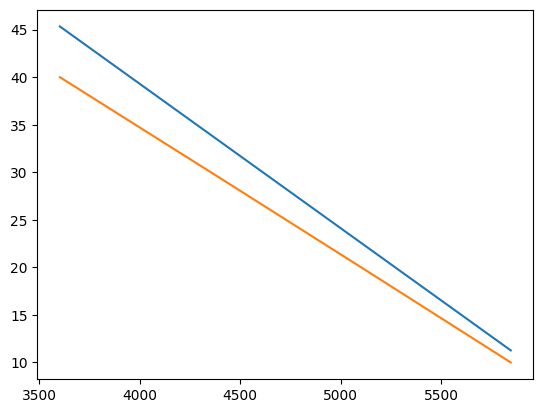

In [23]:
plt.plot(well_state.q_std, well_state.P_in, label='P_in')
plt.plot(well_state.q_std, well_state.P_out, label='P_out')
# plt.xlabel('Давление, атм')

In [9]:
# Первый расчёт:

# Начинаем считать с забоя до Plin,
# граничные условие будуд давление заданные в магистральном трубопроводе и пласте

# Расчитаем первый дебит (начальное распределение):
def slove(Pzab):
    print(type(Pzab))
    Pzab = np.atleast_1d(Pzab)[0]

    if Pzab < 0 or Pzab > resprops.P:
        Pzab = 0
    Pplst = resprops.P
    Pin = compressor.P_in()
    P_bhp = Pplst - Pzab # Начальное забойное давление

    # Расчитываем дебит с начальным BHP:
    Q_gas = well.q(resprops.P,P_bhp)

    # Расчитываем устьевое давление THP:
    THP = wellbore.pwf_to_wh(P_bhp, Q_gas)

    # Расчитаем давление на входе в ДКС
    pipe_out_P = line_pipe.pwf_to_wh(THP,Q_gas)

    # print(f'Q_gas: {Q_gas},DKS_pressure: {compressor.P_in()}, pipe_out_P: {pipe_out_P}')

    delta_pressure = (Pin-pipe_out_P)
    return(delta_pressure)

pres_list = range(5,60,5)
delta = []
for p in pres_list:
    delta.append(slove(p))

Pbhp_slove = scipy.optimize.fsolve(slove,1)[0]


<class 'int'>
<class 'int'>
<class 'int'>
<class 'int'>
<class 'int'>
<class 'int'>
<class 'int'>
<class 'int'>
<class 'int'>
<class 'int'>
<class 'int'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [11]:
Pbhp_slove

np.float64(38.4922995412917)

In [13]:
delta

[-28.474777650945377,
 -24.243863194116578,
 -20.00680794079971,
 -15.762987482747839,
 -11.51184036733273,
 -7.252864409620997,
 -2.9856163936352047,
 1.2902896348444344,
 5.575185490016587,
 9.86935354701113,
 14.17303349418821]

In [12]:
slove(38.4922995412917)

<class 'float'>


2.842170943040401e-14